# Employee Attrition Prediction

## 1. Setup and Data Loading

In [ ]:
# Install necessary libraries
!pip install -q -U scikit-learn
!pip install -q -U imbalanced-learn
!pip install -q -U seaborn

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import BernoulliNB, ComplementNB, GaussianNB, MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.inspection import permutation_importance

from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.metrics import classification_report_imbalanced

# Set display options for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
import pandas as pd


df = pd.read_csv("/content/employee_attrition_dataset_10000 (1).csv")
# Display the first few rows
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,12,3,1,3,2,74,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,7,5,1,2,2,24,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,4,3,4,5,1,63,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,9,1,1,1,2,4,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,9,1,3,4,3,62,No,1,54,11,1,1,1,43,4,No


In [ ]:
# Display concise summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    10000 non-null  int64 
 1   Age                            10000 non-null  int64 
 2   Gender                         10000 non-null  object
 3   Marital_Status                 10000 non-null  object
 4   Department                     10000 non-null  object
 5   Job_Role                       10000 non-null  object
 6   Job_Level                      10000 non-null  int64 
 7   Monthly_Income                 10000 non-null  int64 
 8   Hourly_Rate                    10000 non-null  int64 
 9   Years_at_Company               10000 non-null  int64 
 10  Years_in_Current_Role          10000 non-null  int64 
 11  Years_Since_Last_Promotion     10000 non-null  int64 
 12  Work_Life_Balance              10000 non-null  int64 
 13  Jo

## 2. Data Preprocessing

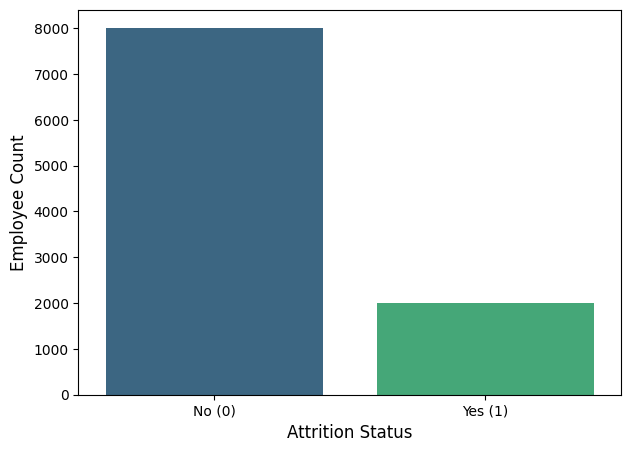

In [ ]:
# Encode the target variable 'Attrition' to numeric format
# 0 for 'No', 1 for 'Yes'
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# ----- Visualize the class distribution using Seaborn -----

plt.figure(figsize=(7, 5))

ax = sns.countplot(x='Attrition', data=df, palette='viridis', legend = False, hue='Attrition')
ax.set_xlabel("Attrition Status", fontsize=12)
ax.set_ylabel("Employee Count", fontsize=12)

plt.xticks(ticks=[0, 1], labels=['No (0)', 'Yes (1)'])
plt.show()

In [ ]:
# Feature Engineering: Drop columns that are identifiers or have high correlation/low importance
features_to_drop = ['Years_in_Current_Role', 'Absenteeism']
processed_df = df.drop(columns=features_to_drop)


In [ ]:
# Separate features (X) and target (y)
X = processed_df.drop('Attrition', axis=1)
y = processed_df['Attrition']

# Identify numeric columns for scaling
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Update numeric features list to reflect dummy variable creation
numeric_features_final = [col for col in numeric_features if col in X_encoded.columns]

In [ ]:
# Performance evaluation function
def print_scores(y_true, y_pred, model_name):
    """
    Prints classification report and accuracy for a given model.
    """
    print(f"Results for {model_name}:")
    print(classification_report_imbalanced(y_true, y_pred, digits=4))
    acc = accuracy_score(y_true, y_pred)
    print(f'Accuracy: {acc:.4f}')
    print("=" * 60)

## 3. Modeling

### Helper Function for Training and Evaluation

In [ ]:
def train_and_evaluate_models(X_train, X_test, y_train, y_test, numeric_cols):
    """
    Scales data, trains multiple Naive Bayes models, and evaluates them.
    """
    # Scale numerical features
    scaler = MinMaxScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

    # Define Naive Bayes models
    models = {
        "BernoulliNB": BernoulliNB(),
        "ComplementNB": ComplementNB(),
        "GaussianNB": GaussianNB(),
        "MultinomialNB": MultinomialNB()
    }

    # Train and evaluate each model
    for name, model in models.items():
        print(f"Training model: {name}")
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        print_scores(y_test, y_pred, name)

### 3.1. Training on Original (Imbalanced) Data

In [ ]:
# Split the original encoded data
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("--- Training on Original Imbalanced Data ---")
train_and_evaluate_models(X_train_raw, X_test_raw, y_train_raw, y_test_raw, numeric_features_final)

--- Training on Original Imbalanced Data ---
Training model: BernoulliNB
Results for BernoulliNB:
                   pre       rec       spe        f1       geo       iba       sup

          0     0.7960    1.0000    0.0000    0.8864    0.0000    0.0000      1592
          1     0.0000    0.0000    1.0000    0.0000    0.0000    0.0000       408

avg / total     0.6336    0.7960    0.2040    0.7056    0.0000    0.0000      2000

Accuracy: 0.7960
Training model: ComplementNB
Results for ComplementNB:
                   pre       rec       spe        f1       geo       iba       sup

          0     0.8094    0.4560    0.5809    0.5834    0.5147    0.2616      1592
          1     0.2149    0.5809    0.4560    0.3137    0.5147    0.2682       408

avg / total     0.6881    0.4815    0.5554    0.5284    0.5147    0.2629      2000

Accuracy: 0.4815
Training model: GaussianNB
Results for GaussianNB:
                   pre       rec       spe        f1       geo       iba       sup

        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 3.2. Training with Undersampling (Edited Nearest Neighbours)

In [ ]:
# Apply EditedNearestNeighbours undersampling
enn = EditedNearestNeighbours(n_neighbors=5)
X_enn, y_enn = enn.fit_resample(X_encoded, y)
print(f"Original shape: {X_encoded.shape}, Shape after ENN: {X_enn.shape}")

# Split the undersampled data
X_train_enn, X_test_enn, y_train_enn, y_test_enn = train_test_split(X_enn, y_enn, test_size=0.2, random_state=42)

print("\n--- Training on Undersampled (ENN) Data ---")
train_and_evaluate_models(X_train_enn, X_test_enn, y_train_enn, y_test_enn, numeric_features_final)

Original shape: (10000, 29), Shape after ENN: (4647, 29)

--- Training on Undersampled (ENN) Data ---
Training model: BernoulliNB
Results for BernoulliNB:
                   pre       rec       spe        f1       geo       iba       sup

          0     0.6067    0.9514    0.0829    0.7409    0.2808    0.0857       556
          1     0.5345    0.0829    0.9514    0.1435    0.2808    0.0720       374

avg / total     0.5776    0.6022    0.4322    0.5007    0.2808    0.0802       930

Accuracy: 0.6022
Training model: ComplementNB
Results for ComplementNB:
                   pre       rec       spe        f1       geo       iba       sup

          0     0.6429    0.4209    0.6524    0.5087    0.5240    0.2682       556
          1     0.4311    0.6524    0.4209    0.5191    0.5240    0.2809       374

avg / total     0.5577    0.5140    0.5593    0.5129    0.5240    0.2733       930

Accuracy: 0.5140
Training model: GaussianNB
Results for GaussianNB:
                   pre       rec   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 3.3. Training with Oversampling (SMOTE)

In [ ]:
# Apply SMOTE oversampling
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_encoded, y)
print(f"Original shape: {X_encoded.shape}, Shape after SMOTE: {X_sm.shape}")


# Split the oversampled data
X_train_sm, X_test_sm, y_train_sm, y_test_sm = train_test_split(X_sm, y_sm, test_size=0.2, random_state=42)

print("\n--- Training on Oversampled (SMOTE) Data ---")
train_and_evaluate_models(X_train_sm, X_test_sm, y_train_sm, y_test_sm, numeric_features_final)

Original shape: (10000, 29), Shape after SMOTE: (16006, 29)

--- Training on Oversampled (SMOTE) Data ---
Training model: BernoulliNB
Results for BernoulliNB:
                   pre       rec       spe        f1       geo       iba       sup

          0     0.7684    0.8032    0.7471    0.7854    0.7746    0.6034      1636
          1     0.7842    0.7471    0.8032    0.7652    0.7746    0.5967      1566

avg / total     0.7761    0.7758    0.7745    0.7755    0.7746    0.6001      3202

Accuracy: 0.7758
Training model: ComplementNB
Results for ComplementNB:
                   pre       rec       spe        f1       geo       iba       sup

          0     0.7526    0.8276    0.7158    0.7884    0.7697    0.5991      1636
          1     0.7990    0.7158    0.8276    0.7551    0.7697    0.5858      1566

avg / total     0.7753    0.7730    0.7705    0.7721    0.7697    0.5926      3202

Accuracy: 0.7730
Training model: GaussianNB
Results for GaussianNB:
                   pre       re

### 3.4. Training with Hybrid Sampling (SMOTEENN)

In [ ]:
# Apply SMOTEENN hybrid sampling
smnn = SMOTEENN(random_state=42, enn=EditedNearestNeighbours(n_neighbors=5))
X_smnn, y_smnn = smnn.fit_resample(X_encoded, y)
print(f"Original shape: {X_encoded.shape}, Shape after SMOTEENN: {X_smnn.shape}")

# Split the hybrid-sampled data
X_train_smnn, X_test_smnn, y_train_smnn, y_test_smnn = train_test_split(X_smnn, y_smnn, test_size=0.2, random_state=42)

print("\n--- Training on Hybrid (SMOTEENN) Data ---")
train_and_evaluate_models(X_train_smnn, X_test_smnn, y_train_smnn, y_test_smnn, numeric_features_final)

Original shape: (10000, 29), Shape after SMOTEENN: (10667, 29)

--- Training on Hybrid (SMOTEENN) Data ---
Training model: BernoulliNB
Results for BernoulliNB:
                   pre       rec       spe        f1       geo       iba       sup

          0     0.8658    0.9690    0.5373    0.9145    0.7215    0.5431      1611
          1     0.8489    0.5373    0.9690    0.6581    0.7215    0.4981       523

avg / total     0.8617    0.8632    0.6431    0.8516    0.7215    0.5321      2134

Accuracy: 0.8632
Training model: ComplementNB
Results for ComplementNB:
                   pre       rec       spe        f1       geo       iba       sup

          0     0.9065    0.8423    0.7323    0.8732    0.7854    0.6236      1611
          1     0.6013    0.7323    0.8423    0.6603    0.7854    0.6101       523

avg / total     0.8317    0.8154    0.7593    0.8211    0.7854    0.6203      2134

Accuracy: 0.8154
Training model: GaussianNB
Results for GaussianNB:
                   pre       r

## 4. Results and Visualization
This section generates the key visualizations from the analysis directly from the code.

### 4.1. Confusion Matrix Comparison

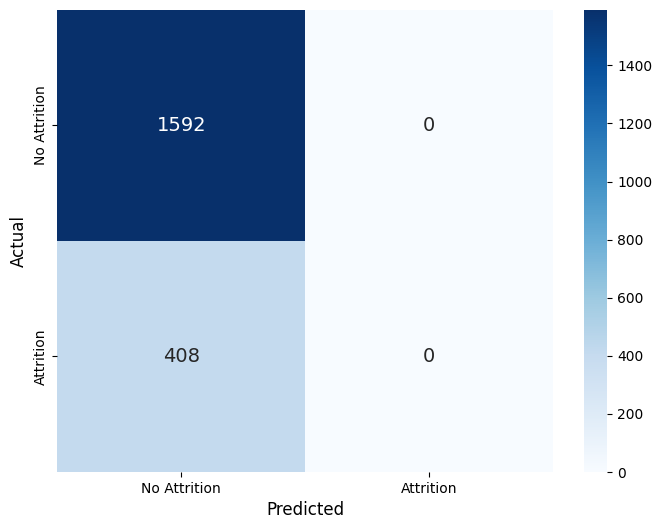

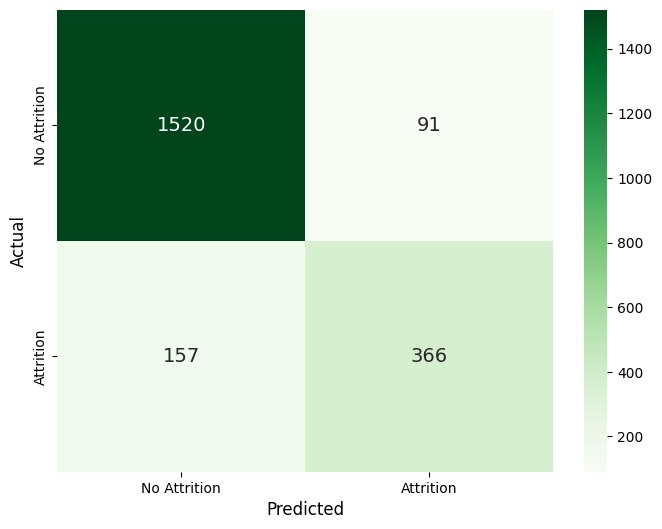

In [ ]:
# ----- Retrain models and get predictions for visualization -----

# 1. Model on Raw Data
scaler_raw = MinMaxScaler()
X_train_raw_scaled = scaler_raw.fit_transform(X_train_raw[numeric_features_final])
X_test_raw_scaled = scaler_raw.transform(X_test_raw[numeric_features_final])

# Create copies to avoid SettingWithCopyWarning
X_train_raw_s = X_train_raw.copy()
X_test_raw_s = X_test_raw.copy()

X_train_raw_s[numeric_features_final] = X_train_raw_scaled
X_test_raw_s[numeric_features_final] = X_test_raw_scaled

model_raw = GaussianNB()
model_raw.fit(X_train_raw_s, y_train_raw)
y_pred_raw = model_raw.predict(X_test_raw_s)
cm_raw = confusion_matrix(y_test_raw, y_pred_raw)

# 2. Model on SMOTE-ENN Data
scaler_smnn = MinMaxScaler()
X_train_smnn_scaled = scaler_smnn.fit_transform(X_train_smnn[numeric_features_final])
X_test_smnn_scaled = scaler_smnn.transform(X_test_smnn[numeric_features_final])

# Create copies to avoid SettingWithCopyWarning
X_train_smnn_s = X_train_smnn.copy()
X_test_smnn_s = X_test_smnn.copy()

X_train_smnn_s[numeric_features_final] = X_train_smnn_scaled
X_test_smnn_s[numeric_features_final] = X_test_smnn_scaled

model_smnn = GaussianNB()
model_smnn.fit(X_train_smnn_s, y_train_smnn)
y_pred_smnn = model_smnn.predict(X_test_smnn_s)
cm_smnn = confusion_matrix(y_test_smnn, y_pred_smnn)

# ----- Plotting -----
class_names = ['No Attrition', 'Attrition']

# Plot 1: Raw Data Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.savefig('confusion_matrix_raw.svg', format='svg')
plt.show()

# Plot 2: SMOTE-ENN Data Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_smnn, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.savefig('confusion_matrix_smnn.svg', format='svg')
plt.show()

### 4.2. Feature Importance

We will calculate the feature importance on the best-performing model (trained on SMOTE-ENN data) using permutation importance. This method measures the decrease in model score when a single feature's values are randomly shuffled, breaking the relationship between the feature and the target.

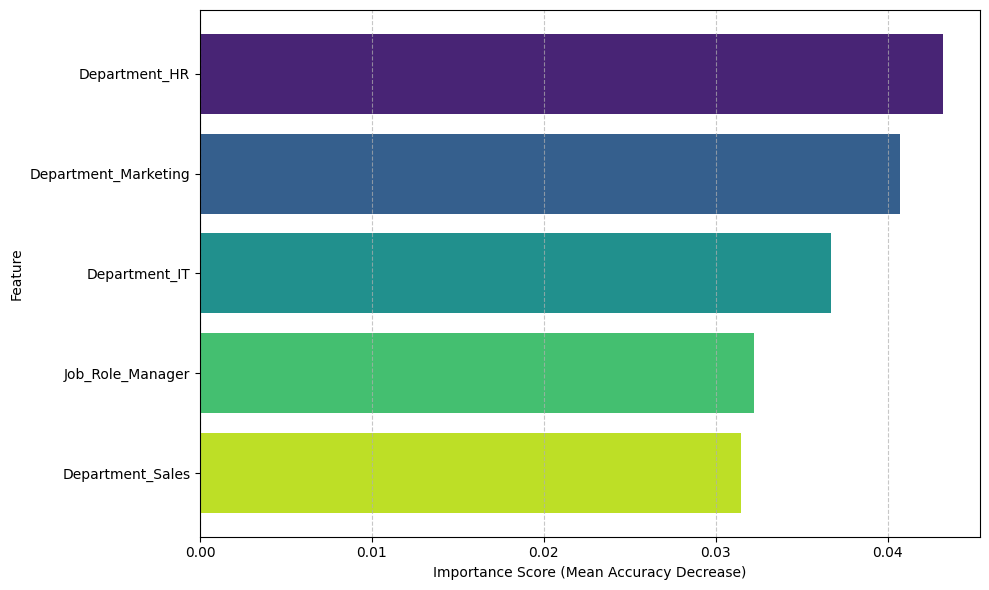

In [ ]:
# Use the scaled SMOTE-ENN test data from the previous step (X_test_smnn_s, y_test_smnn)
# The model is `model_smnn`
result = permutation_importance(
    model_smnn, X_test_smnn_s, y_test_smnn, n_repeats=10, random_state=42, n_jobs=-1
)

# Organize results into a DataFrame
perm_sorted_idx = result.importances_mean.argsort()
perm_importances = pd.DataFrame(
    result.importances[perm_sorted_idx].T,
    columns=X_encoded.columns[perm_sorted_idx],
)

# Select only the features from the original plot for a direct comparison
features_to_plot = [
    'Department_HR',
    'Department_Marketing',
    'Department_Sales',
    'Department_IT',
    'Job_Role_Manager'
]

# Filter the importances for these features
importance_scores = {feat: result.importances_mean[X_encoded.columns.get_loc(feat)] for feat in features_to_plot if feat in X_encoded.columns}

# Sort them for plotting
sorted_importances = sorted(importance_scores.items(), key=lambda item: item[1])
features = [item[0] for item in sorted_importances]
scores = [item[1] for item in sorted_importances]

# ----- Plotting -----
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis_r(np.linspace(0.1, 0.9, len(features)))
plt.barh(features, scores, color=colors)
plt.xlabel("Importance Score (Mean Accuracy Decrease)")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('feature_importance.svg', format='svg')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
#Logistic Regression

print("Logistic Regression (raw data)")
scaler = MinMaxScaler()
X_train_lr = X_train_raw.copy()
X_test_lr = X_test_raw.copy()

X_train_lr[numeric_features_final] = scaler.fit_transform(X_train_raw[numeric_features_final])
X_test_lr[numeric_features_final] = scaler.transform(X_test_raw[numeric_features_final])

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_lr, y_train_raw)

y_pred_lr = model_lr.predict(X_test_lr)
print_scores(y_test_raw, y_pred_lr, "Logistic Regression (raw)")

Logistic Regression (raw data)
Results for Logistic Regression (raw):
                   pre       rec       spe        f1       geo       iba       sup

          0     0.7960    1.0000    0.0000    0.8864    0.0000    0.0000      1592
          1     0.0000    0.0000    1.0000    0.0000    0.0000    0.0000       408

avg / total     0.6336    0.7960    0.2040    0.7056    0.0000    0.0000      2000

Accuracy: 0.7960


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
#Logistic Regression (SMOTE-ENN)
print("Logistic Regression (SMOTE-ENN Data)")

scaler = MinMaxScaler()
X_train_lr = X_train_smnn.copy()
X_test_lr = X_test_smnn.copy()

X_train_lr[numeric_features_final] = scaler.fit_transform(X_train_smnn[numeric_features_final])
X_test_lr[numeric_features_final] = scaler.transform(X_test_smnn[numeric_features_final])

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_lr, y_train_smnn)

y_pred_lr = model_lr.predict(X_test_lr)
print_scores(y_test_smnn, y_pred_lr, "Logistic Regression (SMOTE-ENN)")

Logistic Regression (SMOTE-ENN Data)
Results for Logistic Regression (SMOTE-ENN):
                   pre       rec       spe        f1       geo       iba       sup

          0     0.8959    0.9454    0.6616    0.9200    0.7908    0.6432      1611
          1     0.7972    0.6616    0.9454    0.7231    0.7908    0.6077       523

avg / total     0.8717    0.8758    0.7311    0.8717    0.7908    0.6345      2134

Accuracy: 0.8758


In [ ]:
#decision tree

print(" Decision Tree(SMOTE-ENN)")

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_smnn, y_train_smnn)

y_pred_dt = model_dt.predict(X_test_smnn)
print_scores(y_test_smnn, y_pred_dt, "Decision Tree (SMOTE-ENN)")

 Decision Tree(SMOTE-ENN)
Results for Decision Tree (SMOTE-ENN):
                   pre       rec       spe        f1       geo       iba       sup

          0     0.8925    0.8454    0.6864    0.8683    0.7618    0.5896      1611
          1     0.5905    0.6864    0.8454    0.6348    0.7618    0.5711       523

avg / total     0.8185    0.8065    0.7254    0.8111    0.7618    0.5850      2134

Accuracy: 0.8065


In [ ]:
#random forest

print("Random Forest(SMOTE-ENN Data)")

model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_smnn, y_train_smnn)

y_pred_rf = model_rf.predict(X_test_smnn)
print_scores(y_test_smnn, y_pred_rf, "Random Forest (SMOTE-ENN)")

Random Forest(SMOTE-ENN Data)
Results for Random Forest (SMOTE-ENN):
                   pre       rec       spe        f1       geo       iba       sup

          0     0.9022    0.9907    0.6692    0.9444    0.8142    0.6843      1611
          1     0.9589    0.6692    0.9907    0.7883    0.8142    0.6417       523

avg / total     0.9161    0.9119    0.7480    0.9061    0.8142    0.6739      2134

Accuracy: 0.9119


In [ ]:
#knn
from sklearn.neighbors import KNeighborsClassifier

print("Knn (SMOTE-ENN)")

scaler = MinMaxScaler()
X_train_knn = X_train_smnn.copy()
X_test_knn = X_test_smnn.copy()

X_train_knn[numeric_features_final] = scaler.fit_transform(X_train_smnn[numeric_features_final])
X_test_knn[numeric_features_final] = scaler.transform(X_test_smnn[numeric_features_final])

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_knn, y_train_smnn)

y_pred_knn = model_knn.predict(X_test_knn)
print_scores(y_test_smnn, y_pred_knn, "Knn (SMOTE-ENN)")

Knn (SMOTE-ENN)
Results for Knn (SMOTE-ENN):
                   pre       rec       spe        f1       geo       iba       sup

          0     0.9399    0.8734    0.8279    0.9054    0.8503    0.7264      1611
          1     0.6797    0.8279    0.8734    0.7466    0.8503    0.7198       523

avg / total     0.8761    0.8622    0.8391    0.8665    0.8503    0.7248      2134

Accuracy: 0.8622


In [ ]:
pip install xgboost

In [ ]:
#xgbooost
from xgboost import XGBClassifier

print("XGBoost(SMOTE-ENN)")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_smnn, y_train_smnn)

y_pred_xgb = xgb_model.predict(X_test_smnn)

print_scores(y_test_smnn, y_pred_xgb, "XGBoost (SMOTE-ENN)")

XGBoost(SMOTE-ENN)
Results for XGBoost (SMOTE-ENN):
                   pre       rec       spe        f1       geo       iba       sup

          0     0.9126    0.9783    0.7113    0.9443    0.8342    0.7144      1611
          1     0.9140    0.7113    0.9783    0.8000    0.8342    0.6772       523

avg / total     0.9129    0.9128    0.7767    0.9089    0.8342    0.7053      2134

Accuracy: 0.9128


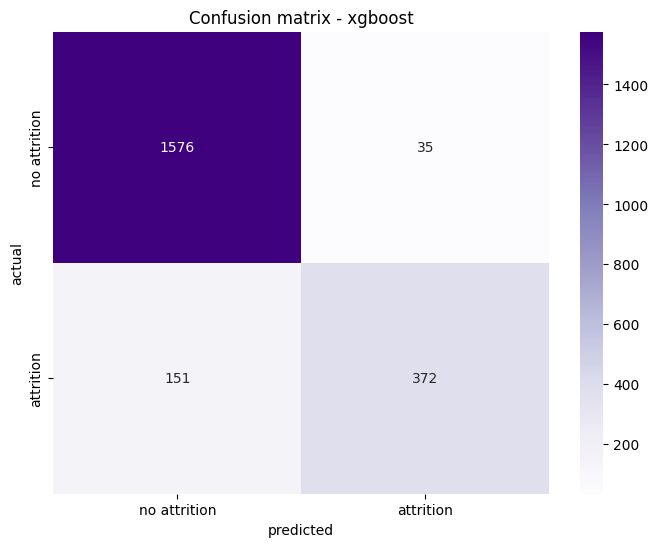

In [ ]:
#confusion matrix

cm_xgb = confusion_matrix(y_test_smnn, y_pred_xgb)

plt.figure(figsize=(8,6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', xticklabels=['no attrition','attrition'], yticklabels=['no attrition','attrition'])

plt.title("Confusion matrix - xgboost")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

XGBoost feature importance
                   Feature  Importance
25      Job_Role_Assistant    0.117111
24        Department_Sales    0.075365
28            Overtime_Yes    0.075318
26      Job_Role_Executive    0.074710
27        Job_Role_Manager    0.072134
19  Marital_Status_Married    0.069513
22           Department_IT    0.059063
23    Department_Marketing    0.057299
20   Marital_Status_Single    0.054575
21           Department_HR    0.051108


/tmp/ipykernel_6417/4199450667.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance',y='Feature',data=importance_df.head(10),palette='viridis')


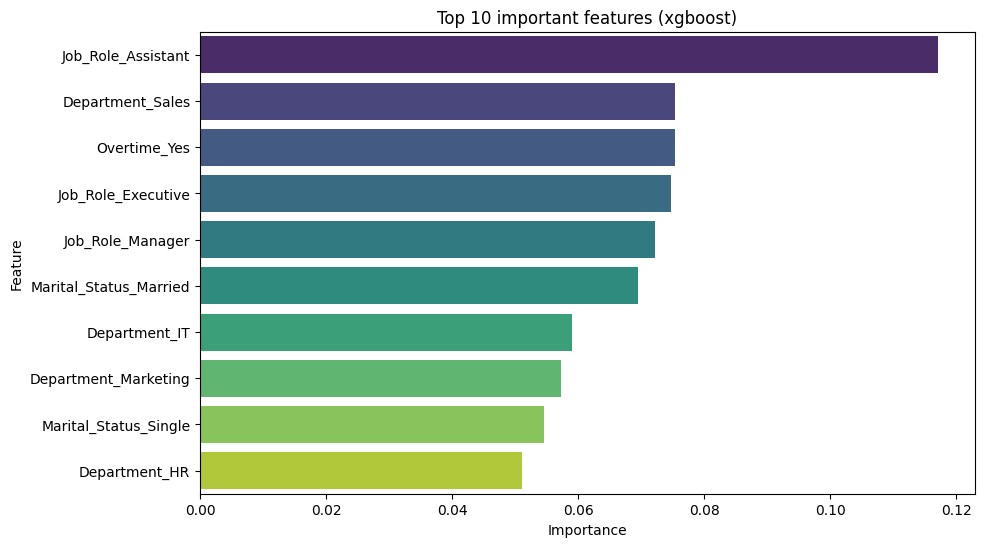

In [ ]:
#importance feature xgbooost
print("XGBoost feature importance")

importances = xgb_model.feature_importances_

importance_df = pd.DataFrame({'Feature': X_encoded.columns,'Importance': importances}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='Feature',data=importance_df.head(10),palette='viridis')
plt.title("Top 10 important features (xgboost)")
plt.show()

In [ ]:
#so sánh các mô hình
print("Model Comparison:")

models = {
    "Logistic": model_lr,"Decision tree": model_dt,"RandomForest": model_rf,"KNN": model_knn,"XGBoost": xgb_model}

for name, model in models.items():
    y_pred = model.predict(X_test_smnn)
    acc = accuracy_score(y_test_smnn, y_pred)
    print(f"{name}: {acc:.4f}")

Model Comparison:
Logistic: 0.7549
Decision tree: 0.8065
RandomForest: 0.9119
KNN: 0.7535
XGBoost: 0.9128


In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=a98f6522529f631712ed3c5eeee6477ca44d6e6032e6c4452104107f0b7546a8
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma



--- Kaplan-Meier Survival Curve ---


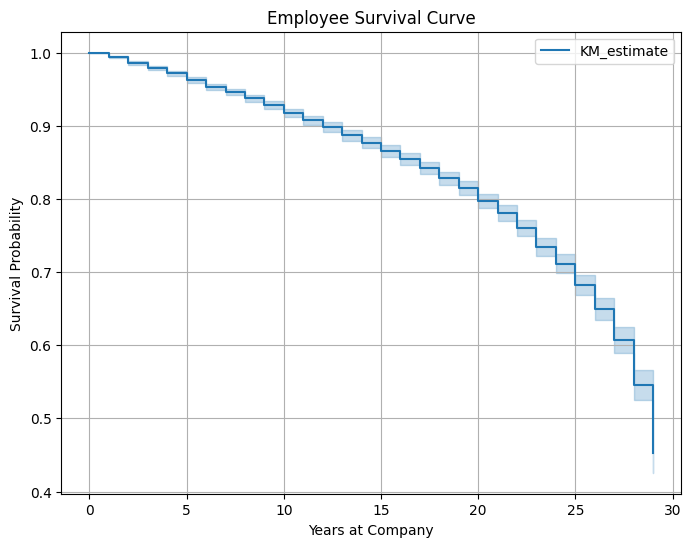

In [ ]:
#survival analysis
#kaplan meier curve
#xác suất nv nghỉ việc theo tgian
from lifelines import KaplanMeierFitter

print("\n--- Kaplan-Meier Survival Curve ---")

kmf = KaplanMeierFitter()

kmf.fit(
    durations=df['Years_at_Company'],
    event_observed=df['Attrition']
)

plt.figure(figsize=(8,6))
kmf.plot_survival_function()
plt.title("Employee Survival Curve")
plt.xlabel("Years at Company")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

In [ ]:
#survival regression
#cox proportional hazads
# yếu tố nào làm tăng nghỉ việc
from lifelines import CoxPHFitter

print("Cox Proportional Hazards Model")

# Survival dataset cần duration + event
survival_df = X_encoded.copy()
survival_df['Years_at_Company'] = df['Years_at_Company']
survival_df['Attrition'] = df['Attrition']

cph = CoxPHFitter()
cph.fit(survival_df, duration_col='Years_at_Company', event_col='Attrition')

cph.print_summary()

Cox Proportional Hazards Model


<lifelines.CoxPHFitter: fitted with 10000 total observations, 8003 right-censored observations>
             duration col = 'Years_at_Company'
                event col = 'Attrition'
      baseline estimation = breslow
   number of observations = 10000
number of events observed = 1997
   partial log-likelihood = -16546.31
         time fit was run = 2026-04-06 13:16:31 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
Employee_ID                   -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Age                            0.00      1.00      0.00           -0.00            0.01                1.00                1.01
Job_Level                      0.02      1.02      0.02           -0.01            0.05                0.99                1.05
Monthly_Income                -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Hourly_Rate                   -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Years_Since_Last_Promotion    -0.00      1.00      0.01           -0.02            0.01                0.98                1.01
Work_Life_Balance              0.03      1.03      0.02           -0.01            0.07                0.99                1.08
Job_Satisfaction               0.01      1.01      0.02           -0.02            0.04                0.98                1.05
Performance_Rating             0.01      1.01      0.02           -0.03            0.05                0.97                1.05
Training_Hours_Last_Year      -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Project_Count                 -0.00      1.00      0.01           -0.02            0.02                0.98                1.02
Average_Hours_Worked_Per_Week  0.00      1.00      0.00           -0.00            0.01                1.00                1.01
Work_Environment_Satisfaction -0.03      0.97      0.02           -0.07            0.01                0.93                1.01
Relationship_with_Manager      0.01      1.01      0.02           -0.03            0.05                0.97                1.05
Job_Involvement                0.02      1.02      0.02           -0.02            0.06                0.98                1.06
Distance_From_Home             0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Number_of_Companies_Worked     0.00      1.00      0.02           -0.04            0.04                0.96                1.04
Gender_Male                    0.05      1.05      0.04           -0.04            0.14                0.96                1.15
Marital_Status_Married        -0.07      0.93      0.05           -0.18            0.04                0.84                1.04
Marital_Status_Single         -0.02      0.98      0.05           -0.12            0.09                0.88                1.09
Department_HR                 -0.03      0.97      0.07           -0.17            0.11                0.85                1.12
Department_IT                 -0.00      1.00      0.07           -0.14            0.13                0.87                1.14
Department_Marketing          -0.06      0.94      0.07           -0.20            0.07                0.82                1.08
Department_Sales              -0.05      0.96      0.07           -0.18            0.09                0.83                1.10
Job_Role_Assistant             0.09      1.09      0.06           -0.03            0.21                0.97                1.23
Job_Role_Executive             0.03      1.03      0.06           -0.09            0.16                0.91                1.17
Job_Role_Manager              -0.12

Survival


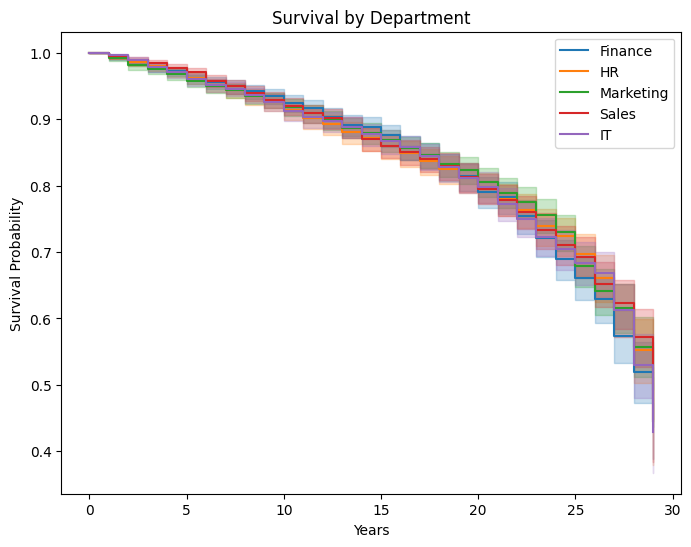

In [ ]:
#survival theo nhóm
#so sánh xs nv tiếp tục làm vc theo tgian giữa các phòng ban
print("Survival")

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for dept in df['Department'].unique():
    mask = df['Department'] == dept
    kmf.fit(df.loc[mask, 'Years_at_Company'], df.loc[mask, 'Attrition'], label=dept)
    kmf.plot_survival_function()

plt.title("Survival by Department")
plt.xlabel("Years")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()
#Sales và HR giảm nhanh hơn, tỉ lệ nghỉ việc cao hơn so với các phòng ban còn lại

In [ ]:
#optimization
#linear programing
#chọn 1 tập nv cần đc ưu tiên giữ lại sao cho tổng lương thấp nhất mà vẫn giữ đc những nv có nguy cơ nghỉ vc cao
from scipy.optimize import linprog

print("Linear Programming Optimization")

# cost = salary
costs = df['Monthly_Income'].values

# risk = predicted attrition probability from logistic model
risk = model_lr.predict_proba(X_test_lr)[:,1]

# Objective: minimize cost while keeping high-risk employees
c = costs[:len(risk)]

# Constraint: must retain at least 80% of high-risk employees
A = [-risk]
b = [-0.8 * risk.sum()]

bounds = [(0,1) for _ in range(len(c))]

res = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

print("Optimization success:", res.success)
print("Selected employees:", sum(res.x > 0.5))

#mô hình đề xuất giữ lại 1042 nv

Linear Programming Optimization
Optimization success: True
Selected employees: 733


# fine-tuning survival

### feature engineering và tăng CH của Cox

In [ ]:
from lifelines.utils import concordance_index
from lifelines.statistics import proportional_hazard_test

In [ ]:
survival_train = X_train_smnn.copy()
survival_train['Years_at_Company'] = survival_train.loc[X_train_smnn.index, 'Years_at_Company']
survival_train['Attrition'] = y_train_smnn
survival_train['Stagnation_Rate'] = survival_train['Years_Since_Last_Promotion'] / (survival_train['Years_at_Company'] + 1)

In [ ]:
survival_train.head(5)

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Gender_Male,Marital_Status_Married,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager,Overtime_Yes,Attrition,Stagnation_Rate
3080,3866,26,2,15149,37,16,9,2,2,3,59,4,58,1,1,1,39,1,False,False,True,False,False,False,False,False,False,False,False,0,0.529412
7917,9895,48,3,15327,51,16,2,1,2,3,8,3,46,3,1,2,21,1,False,False,True,False,True,False,False,False,False,False,True,0,0.117647
906,1147,51,4,10827,73,20,7,2,3,1,84,5,59,3,3,4,30,4,True,False,True,True,False,False,False,False,True,False,False,0,0.333333
8652,3062,49,4,12252,73,9,3,3,3,4,18,5,44,3,2,1,9,2,False,False,False,False,False,False,False,False,False,False,False,1,0.300000
6518,8152,56,3,16307,27,27,9,4,1,4,17,7,34,2,4,2,39,1,False,False,False,False,True,False,False,False,True,False,True,0,0.321429


In [ ]:
cph_improved = CoxPHFitter(penalizer=0.1)
cph_improved.fit(survival_train, duration_col='Years_at_Company', event_col='Attrition')

# 3. Kiểm chứng độ tin cậy (C-index)
c_index_old = cph.concordance_index_ # C-index từ mô hình cũ của bạn
c_index_new = cph_improved.concordance_index_

print(f"Độ tin cậy mô hình cũ: {c_index_old:.4f}")
print(f"Độ tin cậy mô hình cải tiến: {c_index_new:.4f}")
print(f"Mức độ cải thiện: {(c_index_new - c_index_old)/c_index_old:.2%}")

# 4. Kiểm tra giả định Schoenfeld (Chứng minh tính đúng đắn của mô hình)
results = proportional_hazard_test(cph_improved, survival_train, time_transform='rank')
print("\nKiểm tra giả định Proportional Hazards (nếu p > 0.05 là tin cậy):")
results.print_summary()

Độ tin cậy mô hình cũ: 0.5320
Độ tin cậy mô hình cải tiến: 0.8467
Mức độ cải thiện: 59.14%

Kiểm tra giả định Proportional Hazards (nếu p > 0.05 là tin cậy):


### kết hợp XGBoost và Cox

In [ ]:
xgb_train = survival_train.copy()
x_xgb_train = xgb_train.drop(columns=['Attrition'])
y_xgb_train = xgb_train['Attrition']

In [ ]:
test_df = X_test_smnn.copy()
test_df['Years_at_Company'] = test_df.loc[X_test_smnn.index, 'Years_at_Company']
test_df['Stagnation_Rate'] = test_df['Years_Since_Last_Promotion'] / (test_df['Years_at_Company'] + 1)
test_df['Attrition'] = y_test_smnn

In [ ]:
#xgbooost
from xgboost import XGBClassifier

print("XGBoost(SMOTE-ENN)")

xgb_model_new = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model_new.fit(x_xgb_train, y_xgb_train)

y_pred_xgb = xgb_model_new.predict(test_df.drop(columns=['Attrition']))

print_scores(y_test_smnn, y_pred_xgb, "XGBoost (SMOTE-ENN)")

XGBoost(SMOTE-ENN)
Results for XGBoost (SMOTE-ENN):
                   pre       rec       spe        f1       geo       iba       sup

          0     0.9152    0.9777    0.7208    0.9454    0.8395    0.7228      1611
          1     0.9128    0.7208    0.9777    0.8056    0.8395    0.6866       523

avg / total     0.9146    0.9147    0.7838    0.9111    0.8395    0.7140      2134

Accuracy: 0.9147


In [ ]:
#xác suất nghỉ việc từ XGBoost
all_probs = xgb_model_new.predict_proba(test_df.drop(columns=['Attrition']))[:, 1]
all_probs

array([0.88907176, 0.06523882, 0.05296799, ..., 0.8858888 , 0.07138041,
       0.00633773], dtype=float32)

In [ ]:
# Hazard Ratio càng cao nghĩa là rủi ro nghỉ việc đến càng sớm
hazard_scores = cph_improved.predict_partial_hazard(test_df)
hazard_scores

,0
9939,3.123589
3677,0.635593
7081,0.653135
3015,0.239514
7888,4.752684
483,0.303675
5707,2.905294
5910,3.974220
1084,1.342355
7871,0.427434


In [ ]:
#risk_score
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
hazard_normalized = scaler.fit_transform(hazard_scores.values.reshape(-1, 1)).flatten()

In [ ]:
test_df['Risk_Score'] = all_probs * (1 + hazard_normalized)
test_df['Risk_Score']

,Risk_Score
9939,0.907507
3677,0.065463
7081,0.053157
3015,0.036632
7888,0.068229
483,0.028662
5707,0.235493
5910,0.101646
1084,0.209666
7871,0.033132


In [ ]:
test_df['Department'] = 'Unknown'
if 'Department_HR' in test_df.columns and 'Department_Marketing' in test_df.columns and 'Department_Sales' in test_df.columns and 'Department_IT' in test_df.columns:
    test_df.loc[(test_df['Department_HR'] == 0) & (test_df['Department_Marketing'] == 0) & (test_df['Department_Sales'] == 0) & (test_df['Department_IT'] == 0), 'Department'] = 'Finance'
    test_df.loc[test_df['Department_HR'] == 1, 'Department'] = 'HR'
    test_df.loc[test_df['Department_Marketing'] == 1, 'Department'] = 'Marketing'
    test_df.loc[test_df['Department_Sales'] == 1, 'Department'] = 'Sales'
    test_df.loc[test_df['Department_IT'] == 1, 'Department'] = 'IT'

# Select available columns for the drop-off list
drop_off_list = test_df[['Employee_ID','Department', 'Monthly_Income', 'Risk_Score', 'Job_Level']].sort_values(by='Risk_Score', ascending=False)
print(drop_off_list.head(10))

       Employee_ID Department  Monthly_Income  Risk_Score  Job_Level
9979          8306    Finance           12985    1.178974          1
9321          2367    Finance           15483    1.037070          1
10076         5483    Finance           16062    1.016565          2
9195          5206    Finance           14373    1.010067          4
8579          6296    Finance           11962    1.008605          1
8672          6052    Finance            9751    1.006251          2
10417          408    Finance           11349    1.004357          4
8938          1922    Finance            7183    1.002751          4
10404         2804    Finance            9318    1.001584          3
9659          9306    Finance           11196    0.999961          1


In [ ]:
durations_test = test_df['Years_at_Company']
events_test = test_df['Attrition']
c_index = concordance_index(durations_test, -hazard_scores, events_test)
print(f"C-index trên tập Test: {c_index:.4f}")

C-index trên tập Test: 0.8349


In [ ]:
drop_off_list

,Employee_ID,Department,Monthly_Income,Risk_Score,Job_Level
9979,8306,Finance,12985,1.178974,1
9321,2367,Finance,15483,1.037070,1
10076,5483,Finance,16062,1.016565,2
9195,5206,Finance,14373,1.010067,4
8579,6296,Finance,11962,1.008605,1
8672,6052,Finance,9751,1.006251,2
10417,408,Finance,11349,1.004357,4
8938,1922,Finance,7183,1.002751,4
10404,2804,Finance,9318,1.001584,3
9659,9306,Finance,11196,0.999961,1


#optimization

In [ ]:
from scipy.optimize import linprog
import numpy as np


analysis_df = drop_off_list.copy()

def map_replacement_months(level):
    if level <= 1: return 3
    if level == 2: return 4
    if level == 3: return 5
    return 6  # Level 4, 5 cần 6 tháng

analysis_df['Replacement_Months'] = analysis_df['Job_Level'].apply(map_replacement_months)

RETENTION_COST_FACTOR = 0.20

analysis_df['Replacement_Cost'] = analysis_df['Monthly_Income'] * analysis_df['Replacement_Months']
analysis_df['Retention_Cost'] = analysis_df['Monthly_Income'] * 12 * RETENTION_COST_FACTOR

analysis_df['Expected_Loss_Avoided'] = analysis_df['Risk_Score'] * analysis_df['Replacement_Cost']

analysis_df['Net_Expected_Gain'] = analysis_df['Expected_Loss_Avoided'] - analysis_df['Retention_Cost']

final_candidates = analysis_df[analysis_df['Net_Expected_Gain'] > 0].copy()


c = -final_candidates['Net_Expected_Gain'].values

A_ub = []
b_ub = []

A_ub.append(final_candidates['Retention_Cost'].values)
TOTAL_BUDGET = analysis_df['Retention_Cost'].sum() * 0.20
b_ub.append(TOTAL_BUDGET)

A_ub.append(np.ones(len(final_candidates)))
b_ub.append(100)

res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=(0, 1), method='highs')

if res.success:
    final_candidates['Retain_Decision'] = (res.x > 0.5).astype(int)

    retain_list = final_candidates[final_candidates['Retain_Decision'] == 1].sort_values(by='Net_Expected_Gain', ascending=False)

    total_saved = retain_list['Expected_Loss_Avoided'].sum()
    total_spent = retain_list['Retention_Cost'].sum()
    final_roi = total_saved / total_spent if total_spent > 0 else 0

    print(f"Number of retained employees: {len(retain_list)}")
    print(f"Expected loss avoid: {total_saved:,.0f} VNĐ")
    print(f"Total_investment: {total_spent:,.0f} VNĐ")
    print(f"ROI: {final_roi:.2f}")
    print("-" * 50)

    cols_to_show = ['Employee_ID', 'Department', 'Job_Level', 'Risk_Score', 'Net_Expected_Gain', 'Retention_Cost']
    display_cols = [c for c in cols_to_show if c in retain_list.columns]
    display(retain_list[display_cols])


else:
    print("No best optimization ")

Number of retained employees: 100
Expected loss avoid: 7,352,628 VNĐ
Total_investment: 3,561,890 VNĐ
ROI: 2.06
--------------------------------------------------


,Employee_ID,Department,Job_Level,Risk_Score,Net_Expected_Gain,Retention_Cost
10630,2514,Finance,4,0.958736,64701.612861,46320.0
9230,3524,Finance,4,0.949312,63989.386765,46596.0
10223,2700,Finance,4,0.957317,63734.728805,45744.0
9578,2516,Finance,4,0.948176,63511.647803,46344.0
9075,3531,Finance,4,0.943474,63292.957477,46584.0
9545,1705,Finance,4,0.983320,59281.691849,40651.2
8818,5772,Finance,4,0.926815,58786.217312,44635.2
9788,2308,Finance,4,0.954802,58247.509793,41995.2
8762,8683,Finance,4,0.916986,58052.337227,44916.0
8995,2425,Finance,5,0.881770,57378.754733,47640.0


In [ ]:
final_candidates['Retain_Decision']

,Retain_Decision
9979,0
9321,0
10076,1
9195,1
8579,0
8672,0
10417,1
8938,0
10404,0
9659,0


Mean Net Gain: 2,217,024 VNĐ
Xác suất có lãi (Net Gain > 0): 100.00%
Khoảng tin cậy 90%: Từ 1,545,857 đến 2,818,939 VNĐ


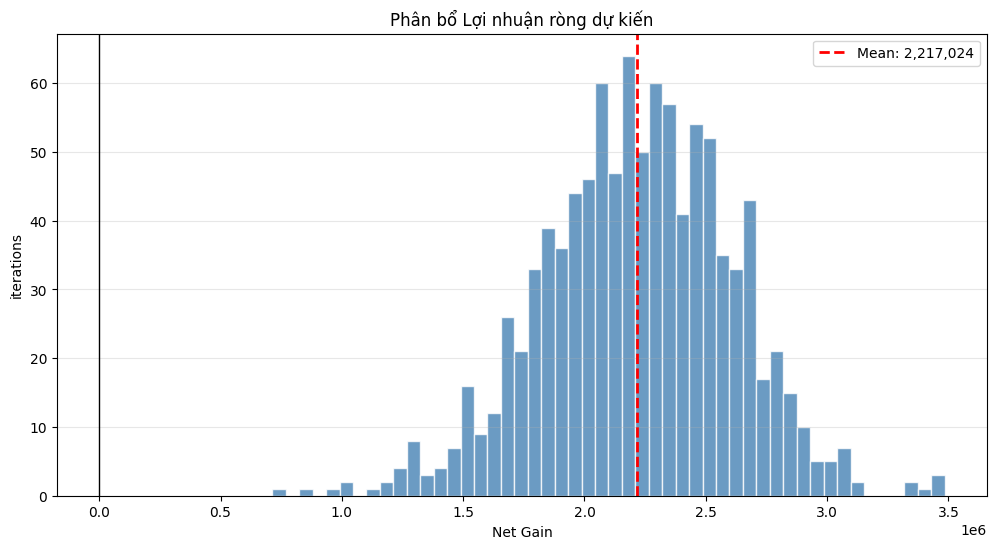

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

retained_list = final_candidates[final_candidates['Retain_Decision'] == 1].copy()

# Xác suất giữ chân thành công là 70%
SUCCESS_PROBABILITY = 0.70
NUM_SIMULATIONS = 1000

total_net_gains = []


for i in range(NUM_SIMULATIONS):
#xác suất cho từng nhân viên trong danh sách 1/0
    success_mask = np.random.rand(len(retained_list)) < SUCCESS_PROBABILITY

    # Replacement_Cost của những người ở lại
    actual_benefit = retained_list.loc[success_mask, 'Replacement_Cost'].sum()

    total_investment = retained_list['Retention_Cost'].sum()

    net_gain = actual_benefit - total_investment
    total_net_gains.append(net_gain)

total_net_gains = np.array(total_net_gains)
mean = total_net_gains.mean()
prob_of_profit = (total_net_gains > 0).mean() * 100
conf_interval = np.percentile(total_net_gains, [5, 95])

print(f"Mean Net Gain: {mean:,.0f} VNĐ")
print(f"Xác suất có lãi (Net Gain > 0): {prob_of_profit:.2f}%")
print(f"Khoảng tin cậy 90%: Từ {conf_interval[0]:,.0f} đến {conf_interval[1]:,.0f} VNĐ")

plt.figure(figsize=(12, 6))
plt.hist(total_net_gains, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean:,.0f}')
plt.axvline(0, color='black', linewidth=1)
plt.title("Phân bổ Lợi nhuận ròng dự kiến")
plt.xlabel("Net Gain")
plt.ylabel("iterations")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()